# Trajectory Analysis for Ablation Training

In [1]:
0

0

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import sys
import logging
import subprocess
import gc
import os
import time
import numpy as np
import pandas as pd
import networkx as nx
import scanpy as sc
import anndata as ad
import pickle
import itertools
import torch
import re
import tqdm
import scvi
import h5py
from scipy import stats

sc.settings.verbose = 3

In [4]:
working_directory = "/home/icb/kemal.inecik/work/codes/sctram"
sys.path.append(working_directory)
sys.path.append("/home/icb/kemal.inecik/work/codes/sctram/reproducibility/server_sync/experiments")

from sctram.api._lower_level import TrajectoryEvaluationAPI
from sctram.generate.real import sc_suo_developmental_complete
from sctram.input import InputTrajectories

2025-05-12 15:12:06.188 | INFO     | sctram.api._defaults_read:load_default_metrics:23 - Loaded default metrics from /home/icb/kemal.inecik/work/codes/sctram/sctram/api/_defaults.yaml
2025-05-12 15:12:06.190 | INFO     | sctram.api._defaults_read:load_default_metrics:79 - Default metrics YAML structure validated successfully.


In [5]:
# Important to have consistent figures across platforms

%matplotlib inline
%config InlineBackend.figure_format='retina'

import pickle

from networkx.drawing.nx_agraph import graphviz_layout
from matplotlib import gridspec
import matplotlib.pyplot as plt
import seaborn as sns
import colorcet as cc
from adjustText import adjust_text  
import matplotlib.patheffects as path_effects

_rcparams_path = os.path.join(working_directory, "reproducibility/figure_rcparams/rcparams.pickle")
with open(_rcparams_path, "rb") as file:
    _rcparams = pickle.load(file)
plt.rcParams.update(_rcparams)

In [6]:
print(f"CUDA used: {torch.cuda.is_available()}")

dataset_dir = "/home/icb/kemal.inecik/lustre_workspace/temp_sctram_data"
helpers_directory = os.path.join(os.getcwd(), "helper")
logs_directory = os.path.join(os.getcwd(), "logs")

CUDA used: True


In [7]:
definitions = dict()
definitions["scvi_dentategyrus_cell"] = {
    "training_anndata_path": os.path.join(dataset_dir, f"scvi_dentategyrus_incremental_with_callback_training_anndata.h5ad"),
    "vae_path": None,
    "pickle_paths_path": os.path.join(dataset_dir, f"scvi_dentategyrus_ablation_cell_settings.pkl"),
    "trajectory_object_path": None,
    "label_obs_column": "ClusterName",
    "batch_obs_column": "SampleID",
}
definitions["scvi_dentategyrus_gene"] = {
    "training_anndata_path": os.path.join(dataset_dir, f"scvi_dentategyrus_incremental_with_callback_training_anndata.h5ad"),
    "vae_path": None,
    "pickle_paths_path": os.path.join(dataset_dir, f"scvi_dentategyrus_ablation_gene_settings.pkl"),
    "trajectory_object_path": None,
    "label_obs_column": "ClusterName",
    "batch_obs_column": "SampleID",
}

### Trajectories for ablation

In [8]:
with h5py.File(definitions["scvi_dentategyrus_gene"]["training_anndata_path"]) as _file_anndata_training:
    adata_training_obs = ad.io.read_elem(_file_anndata_training["obs"])
with open(definitions["scvi_dentategyrus_gene"]["pickle_paths_path"], "rb") as _file_pickle_paths:
    pickle_paths = pickle.load(_file_pickle_paths)[-1]

node_names = set(sorted(adata_training_obs[definitions["scvi_dentategyrus_cell"]["label_obs_column"]].unique()))

In [13]:
ground_truth_trajectories = dict()

ground_truth_trajectories["complex"] = [
    ('Nbl2', 'CA'),
    ('Nbl2', 'ImmGranule1'),
    ('Nbl2', 'Nbl1'),
    ('ImmGranule1', 'ImmGranule2'),
    ('ImmGranule2', 'Granule'),
    ('CA', 'CA1-Sub'),
    ('CA', 'CA2-3-4'),
    ('Nbl1', 'RadialGlia'),
    ('Nbl1', 'nIPC'),
    ('RadialGlia', 'RadialGlia2'),
    ('RadialGlia2', 'ImmAstro'),
    ('nIPC', 'GlialProg'),
    ('GlialProg', 'OPC'),
]

ground_truth_trajectories["less_complex_1"] = [
    ('Nbl2', 'CA'),
    ('Nbl2', 'ImmGranule1'),
    ('Nbl2', 'Nbl1'),
    ('ImmGranule1', 'ImmGranule2'),
    ('ImmGranule2', 'Granule'),
    ('CA', 'CA1-Sub'),
    ('CA', 'CA2-3-4'),
    ('Nbl1', 'RadialGlia'),
    ('RadialGlia', 'RadialGlia2'),
    ('RadialGlia2', 'ImmAstro'),
]

ground_truth_trajectories["less_complex_2"] = [
    ('Nbl2', 'Nbl1'),
    ('Nbl1', 'RadialGlia'),
    ('Nbl1', 'nIPC'),
    ('RadialGlia', 'RadialGlia2'),
    ('RadialGlia2', 'ImmAstro'),
    ('nIPC', 'GlialProg'),
    ('GlialProg', 'OPC'),
]

# ground_truth_trajectories["less_complex_3"] = [
#     ('Nbl2', 'CA'),
#     ('Nbl2', 'Nbl1'),
#     ('CA', 'CA1-Sub'),
#     ('Nbl1', 'RadialGlia'),
#     ('RadialGlia', 'RadialGlia2'),
#     ('RadialGlia2', 'ImmAstro'),
# ]

# ground_truth_trajectories["less_complex_4"] = [
#     ('Nbl2', 'CA'),
#     ('Nbl2', 'ImmGranule1'),
#     ('Nbl2', 'Nbl1'),
#     ('ImmGranule1', 'ImmGranule2'),
#     ('ImmGranule2', 'Granule'),
#     ('CA', 'CA1-Sub'),
#     ('CA', 'CA2-3-4'),
#     ('Nbl1', 'RadialGlia'),
#     ('Nbl1', 'nIPC'),
#     ('RadialGlia', 'RadialGlia2'),
#     ('RadialGlia2', 'ImmAstro'),
#     ('nIPC', 'GlialProg'),
#     ('GlialProg', 'OPC'),
# ]

# ground_truth_trajectories["less_complex_5"] = [
#     ('Nbl2', 'CA'),
#     ('Nbl2', 'ImmGranule1'),
#     ('CA', 'CA1-Sub'),
#     ('CA', 'CA2-3-4'),
#     ('ImmGranule1', 'ImmGranule2'),
#     ('ImmGranule2', 'Granule'),
# ]

# ground_truth_trajectories["less_complex_6"] = [
#     ('Nbl2', 'CA'),
#     ('Nbl2', 'Nbl1'),
#     ('CA', 'CA1-Sub'),
#     ('CA', 'CA2-3-4'),
#     ('Nbl1', 'nIPC'),
#     ('nIPC', 'GlialProg'),
#     ('GlialProg', 'OPC'),
# ]

# ground_truth_trajectories["linear_1"] = [
#     ('Nbl2', 'Nbl1'),
#     ('Nbl1', 'RadialGlia'),
#     ('RadialGlia', 'RadialGlia2'),
#     ('RadialGlia2', 'ImmAstro'),
# ]

# ground_truth_trajectories["linear_2"] = [
#     ('Nbl2', 'Nbl1'),
#     ('Nbl1', 'nIPC'),
#     ('nIPC', 'GlialProg'),
#     ('GlialProg', 'OPC'),
# ]

# ground_truth_trajectories["linear_3"] = [
#     ('Nbl2', 'ImmGranule1'),
#     ('ImmGranule1', 'ImmGranule2'),
#     ('ImmGranule2', 'Granule'),
# ]

# ground_truth_trajectories["linear_4"] = [
#     ('CA1-Sub', 'CA'),
#     ('CA', 'Nbl2'),
#     ('Nbl2', 'ImmGranule1'),
#     ('ImmGranule1', 'ImmGranule2'),
#     ('ImmGranule2', 'Granule'),
# ]

# ground_truth_trajectories["linear_5"] = [
#     ('CA1-Sub', 'CA'),
#     ('CA', 'Nbl2'),
#     ('Nbl2', 'Nbl1'),
#     ('Nbl1', 'RadialGlia'),
#     ('RadialGlia', 'RadialGlia2'),
#     ('RadialGlia2', 'ImmAstro'),
# ]

# ground_truth_trajectories["linear_6"] = [
#     ('CA1-Sub', 'CA'),
#     ('CA', 'Nbl2'),
#     ('Nbl2', 'Nbl1'),
#     ('Nbl1', 'nIPC'),
#     ('nIPC', 'GlialProg'),
#     ('GlialProg', 'OPC'),
# ]

# ground_truth_trajectories["linear_7"] = [
#     ('Granule', 'ImmGranule2'),
#     ('ImmGranule2', 'ImmGranule1'),
#     ('ImmGranule1', 'Nbl2'),
#     ('Nbl2', 'Nbl1'),
#     ('Nbl1', 'RadialGlia'),
#     ('RadialGlia', 'RadialGlia2'),
#     ('RadialGlia2', 'ImmAstro'),
# ]

len(ground_truth_trajectories)

3

In [14]:
# closed calculations due to approaching deadlines 

In [15]:
for k in ground_truth_trajectories:
    _input_trajectory = InputTrajectories(ground_truth_trajectories).get_trajectory(k, include_additional_nodes=False)
    assert all([i in node_names for i in _input_trajectory.nodes()])

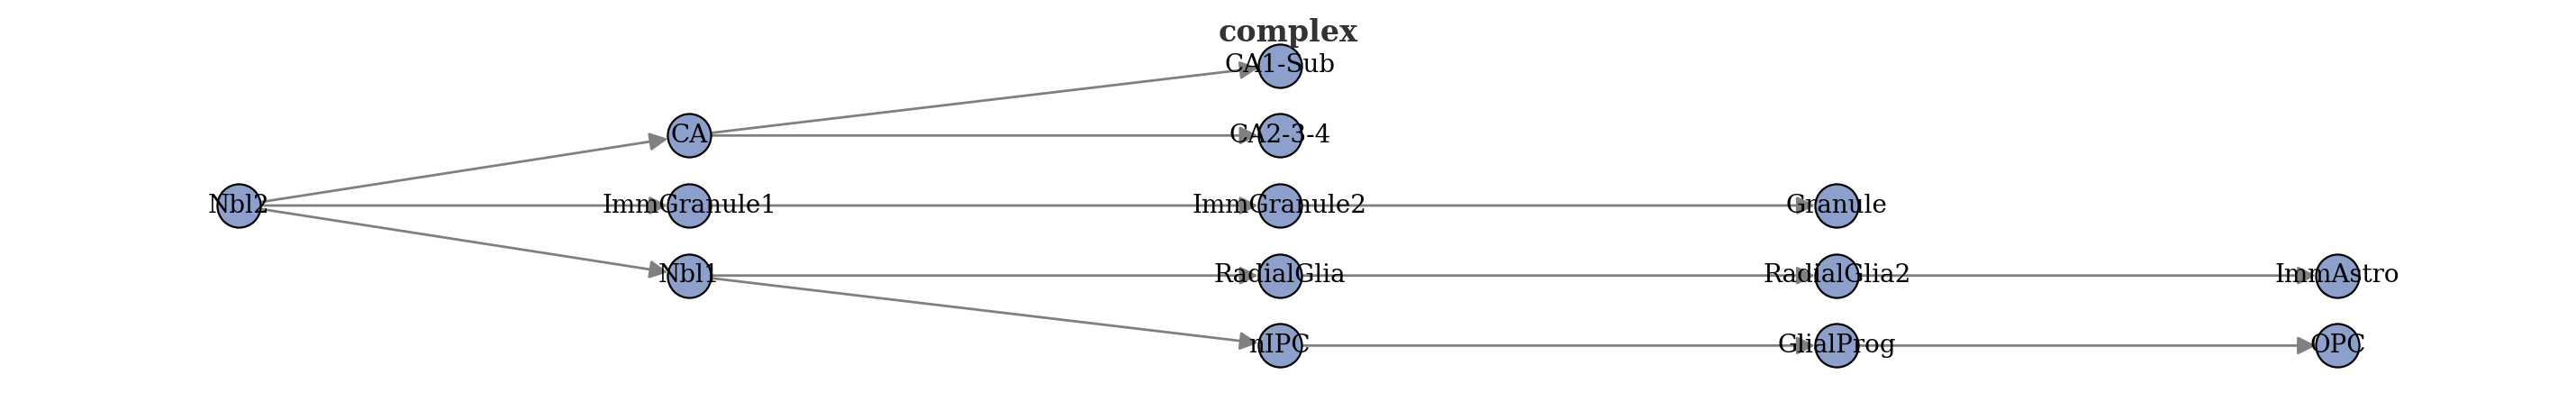

In [16]:
for k in ground_truth_trajectories:
    _input_trajectory = InputTrajectories(ground_truth_trajectories).get_trajectory(k, include_additional_nodes=False)
    _input_trajectory.plot_trajectory(
        title=k,
        figsize=(15, 2), 
        label_offset=0,
    )
    break

In [17]:
trajectory_object = InputTrajectories(ground_truth_trajectories)
_path_of_trajectory_object = os.path.join(dataset_dir, f"scvi_dentategyrus_ablation_gene_cell_trajectory_object.pkl")
definitions["scvi_dentategyrus_gene"]["trajectory_object_path"] = _path_of_trajectory_object
definitions["scvi_dentategyrus_cell"]["trajectory_object_path"] = _path_of_trajectory_object
with open(_path_of_trajectory_object, "wb") as _f:
    pickle.dump(trajectory_object, _f, protocol=pickle.HIGHEST_PROTOCOL)

# Running the benchmarking

In [13]:
list_of_latents = []

run_id = "scvi_dentategyrus_gene"
pickle_paths_path = definitions[run_id]["pickle_paths_path"]
with open(pickle_paths_path, "rb") as _file_pickle_paths:
    steps_paths_dict = pickle.load(_file_pickle_paths)[-1] 
for c2, j in steps_paths_dict.items():
    for c3 in j:
        c4_re = re.search(r'_seed(\d+)\.h5ad$', c3)
        c4 = int(int(c4_re.group(1)))
        list_of_latents.append([run_id, "none", c2, c3, c4])
print(len(list_of_latents))

run_id = "scvi_dentategyrus_cell"
pickle_paths_path = definitions[run_id]["pickle_paths_path"]
with open(pickle_paths_path, "rb") as _file_pickle_paths:
    steps_paths_dict = pickle.load(_file_pickle_paths)[-1] 
for c1, i in steps_paths_dict.items():
    for c2, j in i.items():
        for c3 in j:
            c4_re = re.search(r'_seed(\d+)\.h5ad$', c3)
            c4 = int(int(c4_re.group(1)))
            list_of_latents.append([run_id, c1, c2, c3, c4])
print(len(list_of_latents))

339
4392


In [14]:
list_of_latents.sort(key=lambda x: x[-1])

In [15]:
override = False
count = 0

label_obs_column = definitions[run_id]["label_obs_column"]
trajectory_path = definitions[run_id]["trajectory_object_path"]
warning_already_exist = []

for run_id, c1, c2, c3, c4 in list_of_latents:

    base_job_name = f"{run_id}_c1_{c1}_c2_{c2}_c4_{c4}"
    output_file_path = os.path.join(dataset_dir, f"metric_sctram_{base_job_name}.pkl")
    log_file = os.path.join(logs_directory, f"slurm_out_metric_sctram_{base_job_name}.log")
    slurmjob_name = base_job_name

    if not os.path.exists(c3) or not os.path.isfile(c3):
        print(f"Dataset not yet ready: {base_job_name!r}")
        continue
    
    if override or not os.path.exists(output_file_path) or not os.path.isfile(output_file_path):
        try:
            slurm_script = f"""#!/bin/bash
#SBATCH -J {slurmjob_name}
#SBATCH -p cpu_p
#SBATCH --qos cpu_normal
#SBATCH -c 4
#SBATCH --mem=24G
#SBATCH --nice=0
#SBATCH -t 2:00:00
#SBATCH -o {log_file}
#SBATCH -e {log_file}

source activate sctram_dev_env
python -u {os.path.join(helpers_directory, 'ablation_sctram.py')} --run_id "{run_id}" --c1 "{c1}" --c2 "{c2}" --c3 "{c3}" --c4 "{c4}" --label_obs_column "{label_obs_column}" --trajectory_path "{trajectory_path}" 
"""
            slurm_script_name = os.path.join(logs_directory, f"slurm_job_metric_sctram_{base_job_name}.sh")
            with open(slurm_script_name, "w") as _file_slurm_script:
                _file_slurm_script.write(slurm_script)
            
            print(f"Submitted job: {base_job_name!r}")
            subprocess.run(["sbatch", slurm_script_name])
            count += 1
            # if count > 2:
            #     raise ValueError
        finally:
            # time.sleep(0.1)
            os.remove(slurm_script_name)
    else:
        print(f"Already exist: {base_job_name!r}")
        warning_already_exist.append(base_job_name)

print(f" - Number of jobs submitted: {count}")

Submitted job: 'scvi_dentategyrus_gene_c1_none_c2_0.0_c4_1'
Submitted batch job 36078317
Submitted job: 'scvi_dentategyrus_gene_c1_none_c2_0.025_c4_1'
Submitted batch job 36078318
Submitted job: 'scvi_dentategyrus_gene_c1_none_c2_0.05_c4_1'
Submitted batch job 36078319
Submitted job: 'scvi_dentategyrus_gene_c1_none_c2_0.075_c4_1'
Submitted batch job 36078320
Submitted job: 'scvi_dentategyrus_gene_c1_none_c2_0.1_c4_1'
Submitted batch job 36078321
Submitted job: 'scvi_dentategyrus_gene_c1_none_c2_0.125_c4_1'
Submitted batch job 36078322
Submitted job: 'scvi_dentategyrus_gene_c1_none_c2_0.15_c4_1'
Submitted batch job 36078323
Submitted job: 'scvi_dentategyrus_gene_c1_none_c2_0.175_c4_1'
Submitted batch job 36078324
Submitted job: 'scvi_dentategyrus_gene_c1_none_c2_0.2_c4_1'
Submitted batch job 36078325
Submitted job: 'scvi_dentategyrus_gene_c1_none_c2_0.225_c4_1'
Submitted batch job 36078326
Submitted job: 'scvi_dentategyrus_gene_c1_none_c2_0.25_c4_1'
Submitted batch job 36078327
Submitte

In [16]:
list_of_latents_path = os.path.join(dataset_dir, f"scvi_dentategyrus_ablation_gene_cell_sctram_runs.pkl")
with open(list_of_latents_path, "wb") as _f:
    pickle.dump(list_of_latents, _f, protocol=pickle.HIGHEST_PROTOCOL)

In [19]:
1

1

In [20]:
print(warning_already_exist)

[]
